 Load and visualize at least five images.

In [6]:
import zipfile
import os
import cv2

zip_path = "/content/archive (1).zip"
extract_path = "extracted_images"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Read all images
images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)

print("Total images loaded:", len(images))

Total images loaded: 1100


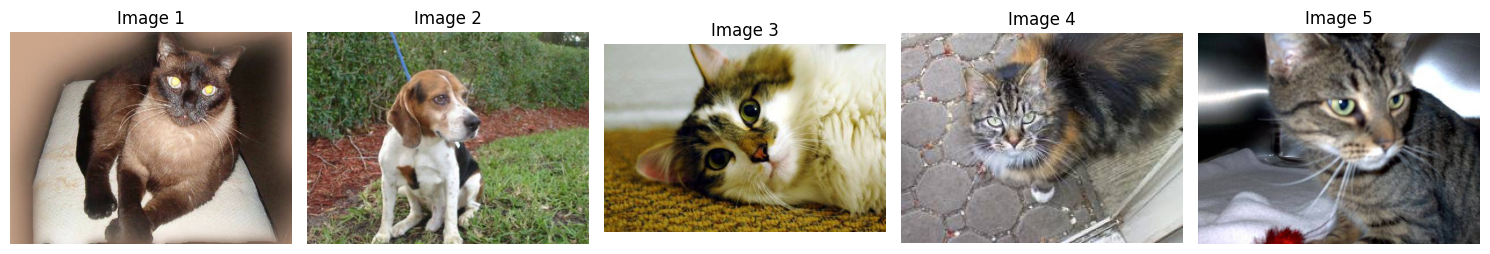

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
for i in range(min(5, len(images))):
    plt.subplot(1, 5, i + 1)

    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
    plt.title(f"Image {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

 Extract image height, width, and channels and store in a table.

In [8]:
import pandas as pd

image_data = []
for i, img in enumerate(images):
    height, width, channels = img.shape
    image_data.append({
        'Image_Index': i,
        'Height': height,
        'Width': width,
        'Channels': channels
    })

image_df = pd.DataFrame(image_data)
display(image_df.head(6))

,Image_Index,Height,Width,Channels
0,0,375,499,3
1,1,375,499,3
2,2,332,499,3
3,3,181,243,3
4,4,374,500,3


Resize all images to 224×224 pixels.

In [9]:
resized_images = []
for img in images:
    resized_img = cv2.resize(img, (224, 224))
    resized_images.append(resized_img)

print(f"Original number of images: {len(images)}")
print(f"Number of resized images: {len(resized_images)}")
print(f"Shape of the first resized image: {resized_images[0].shape}")

Original number of images: 1100
Number of resized images: 1100
Shape of the first resized image: (224, 224, 3)


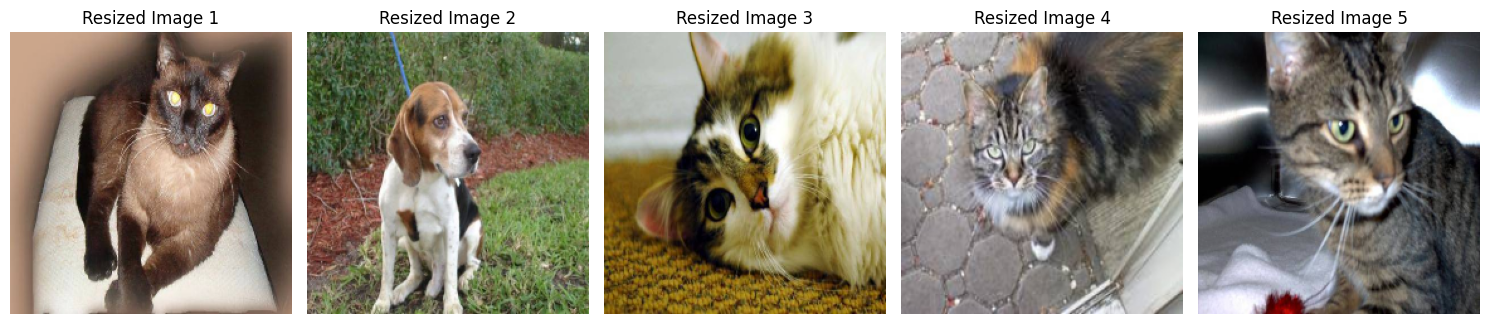

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
for i in range(min(5, len(resized_images))):
    plt.subplot(1, 5, i + 1)
    plt.imshow(cv2.cvtColor(resized_images[i], cv2.COLOR_BGR2RGB))
    plt.title(f"Resized Image {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

Convert images to Grayscale, RGB, and HSV.

Number of grayscale images: 1100
Number of RGB images: 1100
Number of HSV images: 1100


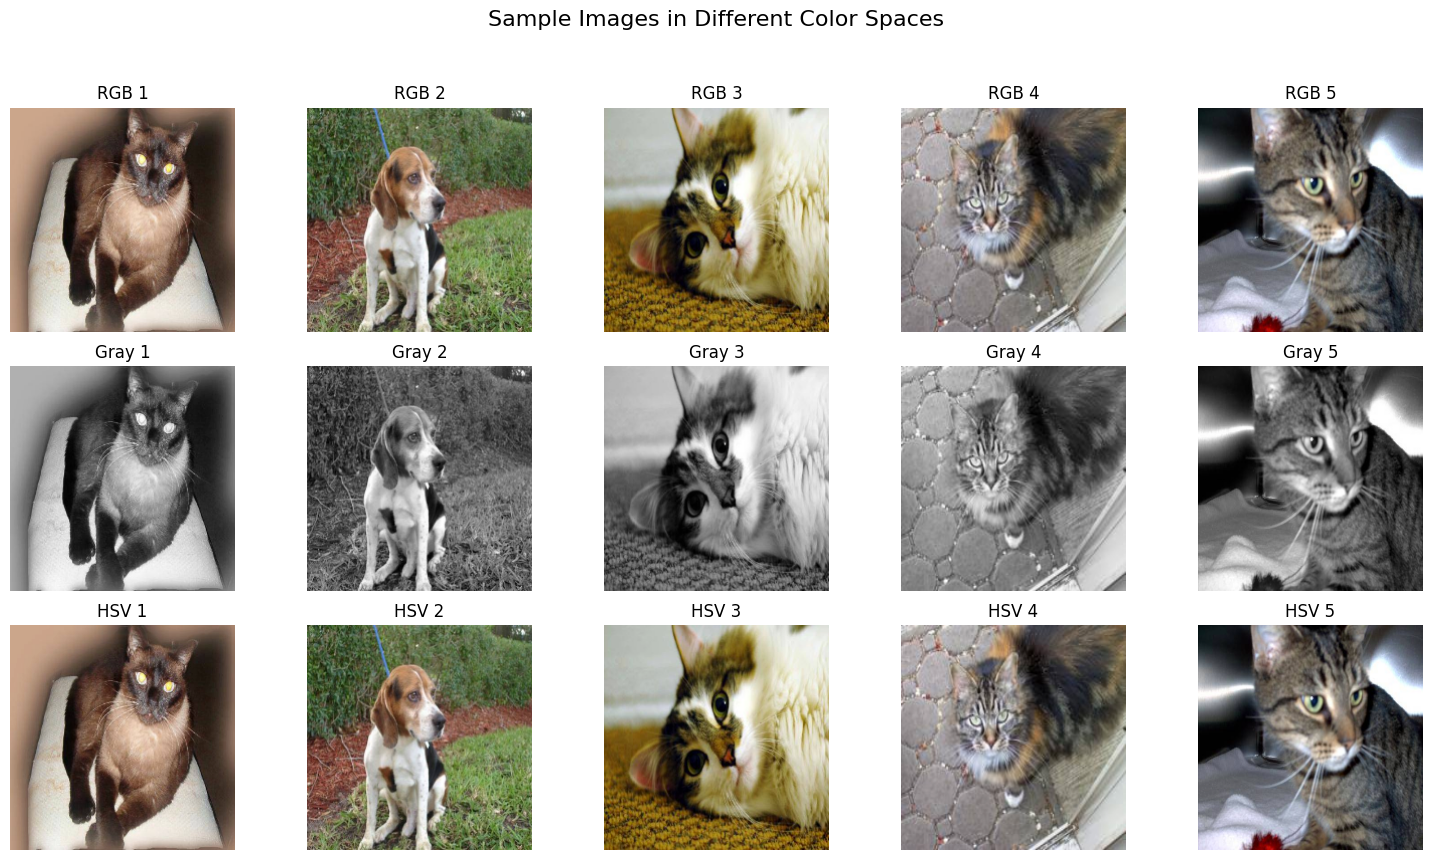

In [11]:
import cv2
import matplotlib.pyplot as plt

grayscale_images = [cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in resized_images]

rgb_images = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB) for img in resized_images]


hsv_images = [cv2.cvtColor(img, cv2.COLOR_BGR2HSV) for img in resized_images]

print(f"Number of grayscale images: {len(grayscale_images)}")
print(f"Number of RGB images: {len(rgb_images)}")
print(f"Number of HSV images: {len(hsv_images)}")


fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Sample Images in Different Color Spaces', fontsize=16)

for i in range(min(5, len(resized_images))):

    axes[0, i].imshow(rgb_images[i])
    axes[0, i].set_title(f'RGB {i+1}')
    axes[0, i].axis('off')


    axes[1, i].imshow(grayscale_images[i], cmap='gray')
    axes[1, i].set_title(f'Gray {i+1}')
    axes[1, i].axis('off')


    axes[2, i].imshow(cv2.cvtColor(hsv_images[i], cv2.COLOR_HSV2RGB))
    axes[2, i].set_title(f'HSV {i+1}')
    axes[2, i].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

 Normalize pixel values from 0–255 to 0–1.

In [12]:

normalized_images = [(img.astype('float32') / 255.0) for img in resized_images]

print(f"Number of normalized images: {len(normalized_images)}")
if normalized_images:
    print(f"Shape of the first normalized image: {normalized_images[0].shape}")
    print(f"Data type of the first normalized image: {normalized_images[0].dtype}")
    print(f"Min pixel value of the first normalized image: {normalized_images[0].min()}")
    print(f"Max pixel value of the first normalized image: {normalized_images[0].max()}")

Number of normalized images: 1100
Shape of the first normalized image: (224, 224, 3)
Data type of the first normalized image: float32
Min pixel value of the first normalized image: 0.0
Max pixel value of the first normalized image: 1.0


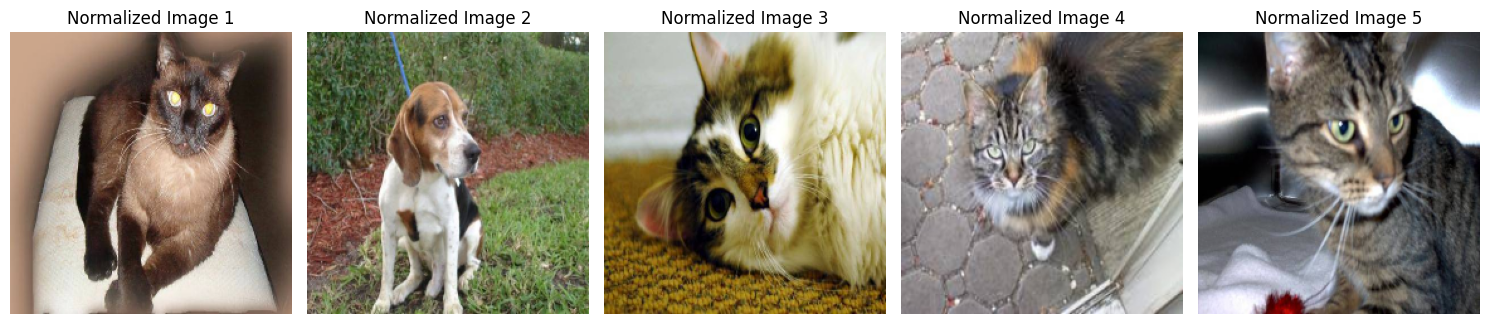

In [13]:
import matplotlib.pyplot as plt

# Display the first 5 normalized images
plt.figure(figsize=(15, 5))
for i in range(min(5, len(normalized_images))):
    plt.subplot(1, 5, i + 1)

    plt.imshow(cv2.cvtColor((normalized_images[i] * 255).astype('uint8'), cv2.COLOR_BGR2RGB))
    plt.title(f"Normalized Image {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

 Data Augmentation (rotation, flips, zoom, brightness adjustment)

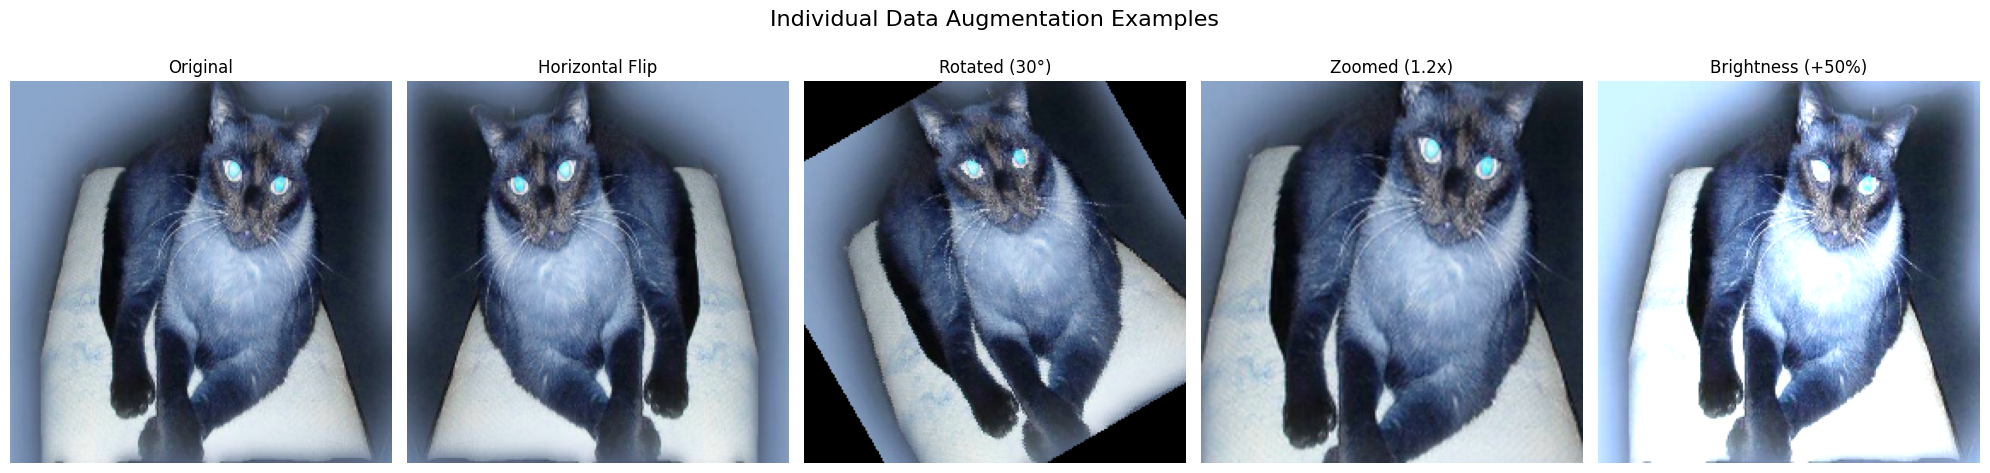

In [22]:
from PIL import Image, ImageEnhance, ImageOps
import numpy as np
import matplotlib.pyplot as plt

# Helper function to convert normalized NumPy array to PIL Image
def to_pil(image_np):
    return Image.fromarray((image_np * 255).astype(np.uint8))

# Helper function to convert PIL Image to normalized NumPy array
def to_numpy(image_pil):
    return np.array(image_pil).astype(np.float32) / 255.0

# Function for Horizontal Flip
def apply_horizontal_flip(image_np):
    image_pil = to_pil(image_np)
    flipped_image_pil = ImageOps.mirror(image_pil) # Horizontal flip
    return to_numpy(flipped_image_pil)

# Function for Rotation
def apply_rotation(image_np, angle):
    image_pil = to_pil(image_np)
    rotated_image_pil = image_pil.rotate(angle)
    return to_numpy(rotated_image_pil)

# Function for Zoom
def apply_zoom(image_np, zoom_factor):
    image_pil = to_pil(image_np)
    width, height = image_pil.size

    new_width, new_height = int(width / zoom_factor), int(height / zoom_factor)
    left = (width - new_width) / 2
    top = (height - new_height) / 2
    right = (width + new_width) / 2
    bottom = (height + new_height) / 2

    cropped_image = image_pil.crop((left, top, right, bottom))
    zoomed_image_pil = cropped_image.resize((width, height), Image.LANCZOS)
    return to_numpy(zoomed_image_pil)

# Function for Brightness Adjustment
def apply_brightness_adjustment(image_np, factor):
    image_pil = to_pil(image_np)
    enhancer = ImageEnhance.Brightness(image_pil)
    brightened_image_pil = enhancer.enhance(factor)
    return to_numpy(brightened_image_pil)


# Select one image for demonstration
sample_image_index = 0
sample_original_image = normalized_images[sample_image_index]

# Apply each augmentation separately
flipped_image = apply_horizontal_flip(sample_original_image)
rotated_image = apply_rotation(sample_original_image, 30) # Rotate by 30 degrees
zoomed_image = apply_zoom(sample_original_image, 1.2) # Zoom in by 20%
bright_image = apply_brightness_adjustment(sample_original_image, 1.5) # Increase brightness by 50%

# Display original and augmented images
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Individual Data Augmentation Examples', fontsize=16)

axes[0].imshow(sample_original_image)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(flipped_image)
axes[1].set_title('Horizontal Flip')
axes[1].axis('off')

axes[2].imshow(rotated_image)
axes[2].set_title('Rotated (30°)')
axes[2].axis('off')

axes[3].imshow(zoomed_image)
axes[3].set_title('Zoomed (1.2x)')
axes[3].axis('off')

axes[4].imshow(bright_image)
axes[4].set_title('Brightness (+50%)')
axes[4].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Create preprocess_image() Function




Shape of original image: (375, 499, 3)
Shape of preprocessed image: (224, 224, 3)
Data type of preprocessed image: float32
Min pixel value of preprocessed image: 0.0
Max pixel value of preprocessed image: 1.0


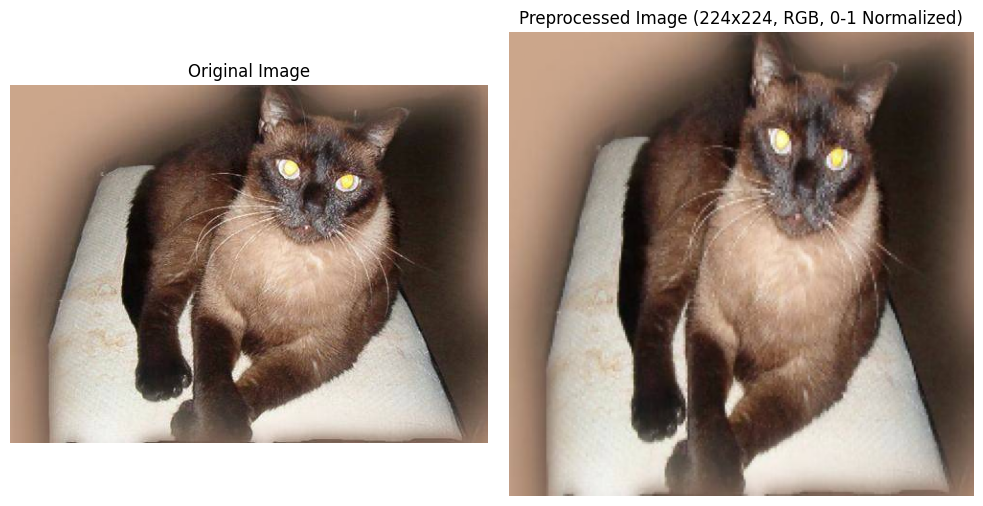

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image(image_bgr):
    """
    Resizes an image to 224x224, converts it from BGR to RGB,
    and normalizes pixel values from 0-255 to 0-1.

    Args:
        image_bgr (numpy.ndarray): The input image in BGR format (0-255 range).

    Returns:
        numpy.ndarray: The preprocessed image in RGB format (0-1 range).
    """
    # Resize to 224x224
    resized_img = cv2.resize(image_bgr, (224, 224))

    # Convert BGR to RGB
    rgb_img = cv2.cvtColor(resized_img, cv2.COLOR_BGR2RGB)

    # Normalize pixel values to 0-1
    normalized_img = rgb_img.astype('float32') / 255.0

    return normalized_img

# Demonstrate the preprocess_image function with an example
# We'll use the first original image loaded (from the 'images' list)
sample_original_bgr_image = images[0]

# Preprocess the image
preprocessed_sample_image = preprocess_image(sample_original_bgr_image)

print(f"Shape of original image: {sample_original_bgr_image.shape}")
print(f"Shape of preprocessed image: {preprocessed_sample_image.shape}")
print(f"Data type of preprocessed image: {preprocessed_sample_image.dtype}")
print(f"Min pixel value of preprocessed image: {preprocessed_sample_image.min()}")
print(f"Max pixel value of preprocessed image: {preprocessed_sample_image.max()}")

# Display original vs. preprocessed image
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(sample_original_bgr_image, cv2.COLOR_BGR2RGB)) # Convert for display
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(preprocessed_sample_image) # Already in RGB and normalized for direct display
plt.title('Preprocessed Image (224x224, RGB, 0-1 Normalized)')
plt.axis('off')

plt.tight_layout()
plt.show()